## **X3**: TT - Separability with Fewer Qubits (k = 8)
* October 6°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

Module 6 found no greater separability for the quantum transformations at the preregistered operating point, $k=12$ qubits (H-039, H-040). Before that result can be read as "the quantum encoding contributes nothing", H-018 left a rule: compare against $k=8$. The reason is measured, not assumed. The embedding of the ZZ feature map concentrates with the number of qubits, with a dispersion of 0.042 at $k=12$ against 0.084 at $k=8$, so a poor result at 12 qubits could be a property of the size rather than of the encoding. The author chose to run the comparison (Q-013).

This notebook changes **only the number of qubits** and repeats Modules 4, 5 and 6 with $k=8$:

- **Module 4.** The same rule: F-test with the redundancy filter $|r|\le0.95$ (D-024) and quantile scaling to $[0,\pi]$ fitted on train (D-025). The selection is greedy, so the 8 features are the first 8 of the 12, and the scaling acts on each feature separately, so their angles do not change. Both statements are verified below, not assumed.
- **Module 5.** The same five conditions: identity, PCA, Kernel PCA with the median-heuristic bandwidth, `zz_feature_map` and `pauli_feature_map(['Y','ZZ'])`, with `reps=1` and the same `real_amplitudes` ansatz. The ansatz has 16 parameters, drawn with seed 42; they are the first 16 numbers of the stream that gave the 24 of $k=12$.
- **Module 6.** The same 200 training lesions per subset (D-028), the same sweep of $c$ (D-029), the same metrics and protocols (D-032, D-033), and the same functions: the cell that defines them is copied verbatim from `6_Separability`.

As a regression check, the metrics of $k=12$ are recomputed here with the same code and compared with the files written by Module 6. The test split is not used.

#### **1° Setup**

**a.** Libraries, parameters and the metric functions of Module 6

In [1]:
import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit
import sklearn
from qiskit.circuit.library import pauli_feature_map, real_amplitudes, zz_feature_map
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from scipy.linalg import eigh
from sklearn.decomposition import PCA, KernelPCA
from sklearn.feature_selection import f_classif
from sklearn.metrics import davies_bouldin_score, pairwise_distances
from sklearn.preprocessing import QuantileTransformer

warnings.filterwarnings('ignore')
SEED, N_PERM, R_MAX = 42, 1000, 0.95
FINDINGS = ['mass', 'calcification']
TITLES = {'mass': 'Masses', 'calcification': 'Calcifications'}
CONDITIONS = ['C1', 'C2', 'C3', 'C4', 'C5']
QUANTUM = ['C4', 'C5']
KS = [12, 8]
SCALES = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02]
LAMBDAS = [1e-5, 1e-4, 1e-3, 1e-2, 0.025, 0.05, 0.1]
MULTIPLIERS = [0.25, 0.5, 1, 2, 4, 8, 16, 32, 64]
EXTENDED = [128, 256, 512]
G_TRA_MAX = 0.045
ROOT = Path('/Users/alexander_san/TT')
M3_DIR, M4_DIR, M5_DIR = (ROOT / f'Data/processed/m{i}' for i in (3, 4, 5))
OUT_DIR = ROOT / 'Data/processed/x3'
RESULTS_DIR, FIG_DIR = ROOT / 'Code/results', ROOT / 'Docs/Figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
COLORS = {'C1': '#eda100', 'C2': '#e87ba4', 'C3': '#2a78d6', 'K_C': '#2a78d6', 'C4': '#eb6834', 'C5': '#1baf7a'}
MARKERS = {'C4': 'o', 'C5': 's'}
INK, NULL_GRAY = '#3d3d3a', '#b9b8b2'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'lines.linewidth': 2, 'lines.markersize': 8})
print(f'qiskit {qiskit.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__} | pandas {pd.__version__}')

qiskit 2.3.0 | numpy 2.2.6 | scikit-learn 1.7.2 | pandas 2.3.3


In [2]:
# Copied verbatim from Code/6_Separability.ipynb (2°b), so that both notebooks compute the same metrics.
def sym(a):
    return (a + a.T) / 2


def normalize_trace(k):
    # Huang et al. assume Tr(K) = N (eq. 5)
    return k * len(k) / np.trace(k)


def psd_sqrt(k):
    # symmetric square root from the eigendecomposition; round-off negative eigenvalues are set to 0
    t, v = eigh(sym(k))
    return (v * np.sqrt(np.clip(t, 0, None))) @ v.T


def top_eigenvalue(m):
    return float(eigh(sym(m), eigvals_only=True)[-1])


def geometric_difference(kq, kc, lambdas):
    # g(K_C || K_Q): eq. (F19) for g_gen and eq. (F20) for g_tra; lambda = 0 gives the unregularized eq. (5)
    sq = psd_sqrt(kq)
    t, v = eigh(sym(kc))
    t = np.clip(t, 0, None)
    out = {}
    for lam in lambdas:
        if lam == 0:
            out[lam] = (np.sqrt(top_eigenvalue(sq @ ((v / t) @ v.T) @ sq)), 0.0) if t.min() > 0 else (np.inf, 0.0)
        else:
            gen = (v * (t / (t + lam) ** 2)) @ v.T          # sqrt(K_C) (K_C + lam I)^-2 sqrt(K_C)
            tra = (v * (1 / (t + lam) ** 2)) @ v.T          # (K_C + lam I)^-2
            out[lam] = (np.sqrt(top_eigenvalue(sq @ gen @ sq)), lam * np.sqrt(top_eigenvalue(sq @ tra @ sq)))
    return out


def center(k):
    # H K H with H = I - 11^T / n
    return k - k.mean(0) - k.mean(1)[:, None] + k.mean()


def alignment_with_null(k, y, perms):
    # uncentered and centered alignment for the observed labels y and for each permuted row of perms (labels +-1)
    n, kc = len(y), center(k)
    yc2 = np.sum((y - y.mean()) ** 2)        # ||H yy^T H||_F; the same for every permutation
    obs_u = y @ k @ y / (np.linalg.norm(k) * n)
    obs_c = y @ kc @ y / (np.linalg.norm(kc) * yc2)
    null_u = np.einsum('pi,ij,pj->p', perms, k, perms) / (np.linalg.norm(k) * n)
    null_c = np.einsum('pi,ij,pj->p', perms, kc, perms) / (np.linalg.norm(kc) * yc2)
    return obs_u, obs_c, null_u, null_c


def effective_dimension(k):
    # eq. (F12) with 1/(N-k+1)
    t = np.sort(np.clip(eigh(sym(normalize_trace(k)), eigvals_only=True), 0, None))[::-1]
    n = len(t)
    tails = np.cumsum(t[::-1])[::-1]             # tails[k-1] = sum of t_l for l >= k
    return float(np.sum(tails / (n - np.arange(n))))


def fisher_ratio(e, y01):
    # squared Mahalanobis distance between class means, pooled within-class covariance
    m0, m1 = e[y01 == 0].mean(0), e[y01 == 1].mean(0)
    r = np.vstack([e[y01 == 0] - m0, e[y01 == 1] - m1])
    diff = m1 - m0
    return float(diff @ np.linalg.solve(r.T @ r / (len(e) - 2), diff))


def linear_alignment(e, ypm):
    # centered alignment of the linear kernel E E^T for one or many +-1 label rows, without the N x N matrix
    ec, rows = e - e.mean(0), np.atleast_2d(ypm)
    num = np.sum((rows @ ec) ** 2, axis=1)
    return num / (np.linalg.norm(ec.T @ ec) * np.sum((rows - rows.mean(1, keepdims=True)) ** 2, axis=1))


def label_permutations(y01, n_perm, seed):
    rng = np.random.default_rng(seed)
    return np.array([rng.permutation(y01) for _ in range(n_perm)])


print('Defined: geometric_difference (eqs. F19-F20), alignment_with_null (uncentered and centered KTA), '
      'effective_dimension (eq. F12 corrected), fisher_ratio, linear_alignment, label_permutations')

Defined: geometric_difference (eqs. F19-F20), alignment_with_null (uncentered and centered KTA), effective_dimension (eq. F12 corrected), fisher_ratio, linear_alignment, label_permutations


#### **2° Module 4 with k = 8**

**a.** Rebuild the selection and the scaling from the 67 features of Module 3, with the rule of Module 4 and $k=8$, and compare them with the first 8 columns that Module 4 wrote for $k=12$

In [3]:
checks = []


def check(name, value, passed):
    checks.append({'check': name, 'value': float(value), 'passed': bool(passed)})


def select(train, features, k, r_max=R_MAX):
    # rule of Module 4 (D-024): descending F, skip a feature whose |r| with one already chosen exceeds r_max
    F, _ = f_classif(train[features].values, train.label.values)
    order = pd.DataFrame({'feature': features, 'F': F}).sort_values(['F', 'feature'], ascending=[False, True]).feature
    corr = train[features].corr().abs()
    chosen = []
    for f in order:
        if all(corr.loc[f, s] <= r_max for s in chosen):
            chosen.append(f)
        if len(chosen) == k:
            break
    return chosen


x8_all, features8 = {}, {}
for ft in FINDINGS:
    m3 = pd.read_parquet(M3_DIR / f'features_{ft}_raw.parquet')
    features = [c for c in m3.columns if c.startswith('original_')]
    train = m3[m3.split == 'train']
    chosen8 = select(train, features, 8)
    m4_features = json.loads((M4_DIR / f'x_{ft}.json').read_text())['features']
    qt = QuantileTransformer(n_quantiles=min(1000, len(train)), output_distribution='uniform',
                             subsample=10**9, random_state=SEED).fit(train[chosen8].values)
    x8 = pd.DataFrame(np.pi * qt.transform(m3[chosen8].values), index=m3.case_id, columns=[f'x_{j:02d}' for j in range(1, 9)])
    m4 = pd.read_parquet(M4_DIR / f'x_{ft}.parquet').set_index('case_id')
    diff = np.abs(x8.loc[m4.index].to_numpy() - m4[[f'x_{j:02d}' for j in range(1, 9)]].to_numpy()).max()
    check(f'{ft}: the 8 features are the first 8 of the 12 of Module 4', 0.0, chosen8 == m4_features[:8])
    check(f'{ft}: the angles of k = 8 equal the first 8 columns of Module 4', diff, diff < 1e-12)
    x8_all[ft], features8[ft] = m4[['patient_id', 'split', 'label', 'fold']].join(x8), chosen8
    dropped = [f.replace('original_', '') for f in m4_features[8:]]
    print(f"{ft:13s}: kept {[f.replace('original_', '') for f in chosen8]}")
    print(f"{'':13s}  dropped {dropped}")
display(pd.DataFrame(checks))

mass         : kept ['firstorder_Maximum', 'firstorder_90Percentile', 'firstorder_Energy', 'shape2D_MinorAxisLength', 'shape2D_MaximumDiameter', 'shape2D_Perimeter', 'shape2D_MeshSurface', 'shape2D_PerimeterSurfaceRatio']
               dropped ['glrlm_GrayLevelNonUniformity', 'firstorder_10Percentile', 'glcm_Correlation', 'glrlm_RunLengthNonUniformity']
calcification: kept ['shape2D_MinorAxisLength', 'glrlm_RunEntropy', 'shape2D_Perimeter', 'firstorder_Skewness', 'glrlm_ShortRunLowGrayLevelEmphasis', 'glrlm_ShortRunEmphasis', 'glcm_JointAverage', 'glcm_InverseVariance']
               dropped ['glcm_DifferenceEntropy', 'firstorder_Energy', 'glcm_ClusterShade', 'shape2D_PixelSurface']


,check,value,passed
0,mass: the 8 features are the first 8 of the 12...,0.0,True
1,mass: the angles of k = 8 equal the first 8 co...,0.0,True
2,calcification: the 8 features are the first 8 ...,0.0,True
3,calcification: the angles of k = 8 equal the f...,0.0,True


#### **3° Module 5 with k = 8**

**a.** The five conditions for every lesion, with exact local Z expectations

The circuits are those of Module 5 with 8 qubits: 28 ZZ pair blocks instead of 66, and an ansatz with 7 CX gates and 16 rotations. C2 and C3 are fitted on train only, as in 5a.

In [4]:
K8 = 8
ansatz8 = real_amplitudes(K8, reps=1)
theta8 = np.random.default_rng(SEED).uniform(0, 2 * np.pi, ansatz8.num_parameters)
theta12 = np.array(json.loads((M5_DIR / 'emb_meta.json').read_text())['theta'])
check('theta of k = 8 is the first 16 draws of the seed-42 stream of k = 12', np.abs(theta8 - theta12[:16]).max(),
      np.array_equal(theta8, theta12[:16]))
maps8 = {'C4': zz_feature_map(K8, reps=1), 'C5': pauli_feature_map(K8, reps=1, paulis=['Y', 'ZZ'])}
signs8 = 1.0 - 2.0 * ((np.arange(2 ** K8)[:, None] >> np.arange(K8)) & 1)


def circuit8(fm, x):
    values = {p: float(v) for p, v in zip(fm.parameters, x)}
    values.update({p: float(v) for p, v in zip(ansatz8.parameters, theta8)})
    return fm.compose(ansatz8).assign_parameters(values, inplace=False)


def local_z(fm, x):
    return Statevector.from_instruction(circuit8(fm, x)).probabilities() @ signs8


def median_gamma(x_train):
    sq = pairwise_distances(x_train, metric='sqeuclidean')
    return 1.0 / (2.0 * np.median(sq[np.triu_indices_from(sq, k=1)]))


emb8, gamma8 = {}, {}
for ft in FINDINGS:
    frame = x8_all[ft]
    x = frame[[f'x_{j:02d}' for j in range(1, 9)]].to_numpy(float)
    train = frame.split.eq('train').to_numpy()
    gamma8[ft] = median_gamma(x[train])
    reps = {'C1': x.copy(), 'C2': PCA(n_components=K8, random_state=SEED).fit(x[train]).transform(x),
            'C3': KernelPCA(n_components=K8, kernel='rbf', gamma=gamma8[ft]).fit(x[train]).transform(x)}
    t0 = time.perf_counter()
    for q in QUANTUM:
        reps[q] = np.vstack([local_z(maps8[q], row) for row in x])
    elapsed = time.perf_counter() - t0
    out = frame[['patient_id', 'split', 'label', 'fold']].copy()
    for c in CONDITIONS:
        out = out.join(pd.DataFrame(reps[c], index=frame.index, columns=[f'{c}_{j:02d}' for j in range(1, 9)]))
    out.reset_index().to_parquet(OUT_DIR / f'emb_k8_{ft}.parquet', index=False)
    emb8[ft] = out
    for i in range(3):
        sv = Statevector.from_instruction(circuit8(maps8['C4'], x[i]))
        ref = [sv.expectation_value(SparsePauliOp('I' * (K8 - 1 - j) + 'Z' + 'I' * j)).real for j in range(K8)]
        err = np.abs(np.array(ref) - reps['C4'][i]).max()
        check(f'{ft}: C4 local Z agrees with SparsePauliOp (lesion {i})', err, err < 1e-12)
    d1, d2 = pairwise_distances(reps['C1'][train]), pairwise_distances(reps['C2'][train])
    check(f'{ft}: C1 and C2 keep the same train distances', np.abs(d1 - d2).max(), np.abs(d1 - d2).max() < 1e-10)
    print(f"{ft:13s}: {len(out)} lesions, gamma = {gamma8[ft]:.4f}, C4 + C5 exact evaluation {elapsed:.1f} s; "
          f"mean per-dimension std over train: C4 {reps['C4'][train].std(0).mean():.3f}, C5 {reps['C5'][train].std(0).mean():.3f}")
display(pd.DataFrame(checks).tail(9))

mass         : 1696 lesions, gamma = 0.0537, C4 + C5 exact evaluation 7.3 s; mean per-dimension std over train: C4 0.099, C5 0.276


calcification: 1872 lesions, gamma = 0.0472, C4 + C5 exact evaluation 8.3 s; mean per-dimension std over train: C4 0.076, C5 0.267


,check,value,passed
4,theta of k = 8 is the first 16 draws of the se...,0.000000e+00,True
5,mass: C4 local Z agrees with SparsePauliOp (le...,8.326673e-17,True
6,mass: C4 local Z agrees with SparsePauliOp (le...,3.868433e-16,True
7,mass: C4 local Z agrees with SparsePauliOp (le...,2.151057e-16,True
8,mass: C1 and C2 keep the same train distances,2.315995e-13,True
9,calcification: C4 local Z agrees with SparsePa...,2.515349e-16,True
10,calcification: C4 local Z agrees with SparsePa...,1.734723e-16,True
11,calcification: C4 local Z agrees with SparsePa...,1.387779e-16,True
12,calcification: C1 and C2 keep the same train d...,6.025735e-14,True


**b.** Fidelity kernels and classical RBF kernel on the 200 lesions of Module 5, for every scale $c$

The lesions and their order are read from the kernel files of Module 5, so that both values of $k$ use exactly the same rows. As in 5b, the RBF bandwidth is the median heuristic on the full training split.

In [5]:
def rbf(x, gamma):
    return np.exp(-gamma * pairwise_distances(x, metric='sqeuclidean'))


kernels8 = {}
for ft in FINDINGS:
    z12 = np.load(M5_DIR / f'kernels_{ft}.npz', allow_pickle=True)
    case_id = z12['case_id'].astype(str)
    x = x8_all[ft].loc[case_id, [f'x_{j:02d}' for j in range(1, 9)]].to_numpy(float)
    ks = {'K_C': rbf(x, gamma8[ft])}
    for q in QUANTUM:
        for c in SCALES:
            ks[f'K_Q_{q}_c{c}'] = FidelityStatevectorKernel(feature_map=maps8[q]).evaluate(c * x)
        ks[f'K_Q_{q}'] = ks[f'K_Q_{q}_c1.0']
    np.savez_compressed(OUT_DIR / f'kernels_k8_{ft}.npz', case_id=case_id, label=z12['label'], gamma=np.array(gamma8[ft]), **ks)
    kernels8[ft] = ks
    worst = max(abs(np.trace(k) - len(k)) for k in ks.values())
    check(f'{ft}: every k = 8 kernel has trace N', worst, worst < 1e-9)
    fm = maps8['C4']
    s0, s1 = (Statevector(fm.assign_parameters(dict(zip(fm.parameters, x[i])))) for i in (0, 1))
    err = abs(ks['K_Q_C4'][0, 1] - abs(s0.inner(s1)) ** 2)
    check(f'{ft}: a C4 kernel entry agrees with the statevector overlap', err, err < 1e-12)
    off = lambda k: k[~np.eye(len(k), dtype=bool)]
    print(f"{ft:13s}: median off-diagonal at c = 1 -> K_C {np.median(off(ks['K_C'])):.3f}, "
          f"C4 {np.median(off(ks['K_Q_C4'])):.4f}, C5 {np.median(off(ks['K_Q_C5'])):.5f}")
display(pd.DataFrame(checks).tail(4))

mass         : median off-diagonal at c = 1 -> K_C 0.604, C4 0.0101, C5 0.00148


calcification: median off-diagonal at c = 1 -> K_C 0.625, C4 0.0077, C5 0.00076


,check,value,passed
13,mass: every k = 8 kernel has trace N,0.0,True
14,mass: a C4 kernel entry agrees with the statev...,0.0,True
15,calcification: every k = 8 kernel has trace N,0.0,True
16,calcification: a C4 kernel entry agrees with t...,0.0,True


#### **4° Module 6 for both k**

**a.** Assemble, for each $k$ and subset, the inputs that Module 6 uses: the 200 lesions with their kernels, angles and embeddings, and the full training split for the robustness check

In [6]:
inputs = {}
for ft in FINDINGS:
    z12 = np.load(M5_DIR / f'kernels_{ft}.npz', allow_pickle=True)
    case_id, y01 = z12['case_id'].astype(str), z12['label'].astype(int)
    emb12 = pd.read_parquet(M5_DIR / f'emb_{ft}.parquet').set_index('case_id')
    x12 = pd.read_parquet(M4_DIR / f'x_{ft}.parquet').set_index('case_id')
    for k, emb, kern, gamma, xcols in [
            (12, emb12, {key: z12[key] for key in z12.files if key.startswith('K_')}, float(z12['gamma']), [f'x_{j:02d}' for j in range(1, 13)]),
            (8, emb8[ft], kernels8[ft], gamma8[ft], [f'x_{j:02d}' for j in range(1, 9)])]:
        cols = lambda c: [f'{c}_{j:02d}' for j in range(1, k + 1)]
        train = emb[emb.split == 'train']
        sub = emb.loc[case_id]
        assert np.array_equal(sub.label.to_numpy(), y01)
        inputs[(k, ft)] = {'y01': y01, 'y': 2 * y01 - 1, 'kernels': kern, 'gamma_d027': gamma,
                           'x': (x12 if k == 12 else x8_all[ft]).loc[case_id, xcols].to_numpy(float),
                           'emb': {c: sub[cols(c)].to_numpy(float) for c in CONDITIONS},
                           'emb_train': {c: train[cols(c)].to_numpy(float) for c in CONDITIONS},
                           'y01_train': train.label.to_numpy(int)}
for (k, ft), d in inputs.items():
    print(f"k = {k:2d}, {ft:13s}: {len(d['y01'])} lesions in the subsample, {len(d['y01_train'])} in train, "
          f"{len(d['kernels'])} kernels, angles {d['x'].shape}, gamma {d['gamma_d027']:.4f}")

k = 12, mass         : 200 lesions in the subsample, 1318 in train, 15 kernels, angles (200, 12), gamma 0.0322
k =  8, mass         : 200 lesions in the subsample, 1318 in train, 15 kernels, angles (200, 8), gamma 0.0537
k = 12, calcification: 200 lesions in the subsample, 1546 in train, 15 kernels, angles (200, 12), gamma 0.0321
k =  8, calcification: 200 lesions in the subsample, 1546 in train, 15 kernels, angles (200, 8), gamma 0.0472


**b.** Family A: alignment, effective dimension and geometric difference, with exactly the procedures of Module 6

In [7]:
def classical_suite(x, multipliers):
    n_feat, var = x.shape[1], x.var()
    sq = ((x[:, None, :] - x[None, :, :]) ** 2).sum(-1)
    xc = x - x.mean(0)
    suite = {'linear': (np.nan, normalize_trace(xc @ xc.T), 'paper')}
    for m in multipliers:
        suite[f'gaussian {m:g}'] = (m / (n_feat * var), np.exp(-(m / (n_feat * var)) * sq),
                                    'paper' if m in MULTIPLIERS else 'extended')
    return suite


def closest(rows):
    adm = rows[rows.admissible]
    if adm.empty:
        return None, 0
    per_kernel = adm.sort_values('lam').groupby('classical_kernel').tail(1)
    return per_kernel.loc[per_kernel.g_gen.idxmin()], len(per_kernel)


kernel_keys = [('K_C', np.nan, 'K_C')] + [(q, c, f'K_Q_{q}_c{c}') for q in QUANTUM for c in SCALES]
kta_rows, dim_rows, g_rows = [], [], []
t0 = time.perf_counter()
for (k, ft), d in inputs.items():
    perms = 2 * label_permutations(d['y01'], N_PERM, SEED) - 1
    for name, c, key in kernel_keys:
        kmat = d['kernels'][key]
        u, cen, nu, nc = alignment_with_null(kmat, d['y'], perms)
        kta_rows.append({'k': k, 'finding_type': ft, 'kernel': name, 'c': c, 'kta_centered': cen,
                         'excess_centered': cen - nc.mean(), 'p_centered': (1 + np.sum(nc >= cen)) / (1 + N_PERM),
                         'median_off_diagonal': float(np.median(kmat[~np.eye(len(kmat), dtype=bool)]))})
        dim_rows.append({'k': k, 'finding_type': ft, 'kernel': name, 'c': c, 'effective_dimension': effective_dimension(kmat)})
    suite = classical_suite(d['x'], MULTIPLIERS + EXTENDED)
    suite['gaussian D-027'] = (d['gamma_d027'], d['kernels']['K_C'], 'D-027')
    refs = [(q, c, d['kernels'][f'K_Q_{q}_c{c}']) for q in QUANTUM for c in SCALES] + [('identity', np.nan, np.eye(len(d['y'])))]
    for q, c, kq in refs:
        for kname, (gamma, kc, grid) in suite.items():
            lams = LAMBDAS + ([0] if grid == 'D-027' else [])
            for lam, (g_gen, g_tra) in geometric_difference(kq, kc, lams).items():
                g_rows.append({'k': k, 'finding_type': ft, 'map': q, 'c': c, 'classical_kernel': kname, 'grid': grid,
                               'gamma': gamma, 'lam': lam, 'g_gen': g_gen, 'g_tra': g_tra,
                               'admissible': bool(lam > 0 and g_tra < G_TRA_MAX)})
kta, dims, gdf = pd.DataFrame(kta_rows), pd.DataFrame(dim_rows), pd.DataFrame(g_rows)
summary_rows = []
for (k, ft, q, c), part in gdf.groupby(['k', 'finding_type', 'map', 'c'], sort=False, dropna=False):
    best, n_adm = closest(part[part.grid == 'paper'])
    best_ext, _ = closest(part[part.grid.isin(['paper', 'extended'])])
    summary_rows.append({'k': k, 'finding_type': ft, 'map': q, 'c': c,
                         'g_min': np.nan if best is None else best.g_gen,
                         'kernel_at_min': None if best is None else best.classical_kernel,
                         'lambda_at_min': np.nan if best is None else best.lam,
                         'g_min_extended': np.nan if best_ext is None else best_ext.g_gen,
                         'admissible_kernels': n_adm})
gsum = pd.DataFrame(summary_rows)
print(f'family A computed in {time.perf_counter() - t0:.0f} s: {len(kta)} alignments, {len(gdf)} grid points of g')
show = lambda df: df.assign(c=df.c.map(lambda v: '—' if pd.isna(v) else f'{v:g}'))
display(show(kta[kta.c.isna() | (kta.c == 1.0)]).pivot(index=['finding_type', 'kernel'], columns='k',
        values=['excess_centered', 'p_centered', 'median_off_diagonal'])[[(m, k) for m in ['excess_centered', 'p_centered', 'median_off_diagonal'] for k in KS]].round(5))
display(show(gsum[gsum.c.isna() | (gsum.c == 1.0)]).pivot(index=['finding_type', 'map'], columns='k',
        values=['g_min', 'g_min_extended'])[[(m, k) for m in ['g_min', 'g_min_extended'] for k in KS]].round(3))

family A computed in 30 s: 52 alignments, 5148 grid points of g


excess_centered          p_centered         \
k                                 12       8          12     8    
finding_type  kernel                                              
calcification C4             0.00620  0.01077      0.001  0.001   
              C5             0.00658  0.02445      0.003  0.001   
              K_C            0.15145  0.14982      0.001  0.001   
mass          C4             0.00300  0.01220      0.002  0.002   
              C5             0.00505  0.02315      0.003  0.002   
              K_C            0.04911  0.04870      0.001  0.001   

                     median_off_diagonal           
k                                     12       8   
finding_type  kernel                               
calcification C4                 0.00286  0.00775  
              C5                 0.00003  0.00076  
              K_C                0.62389  0.62485  
mass          C4                 0.00216  0.01011  
              C5                 0.00003  0.00148  
              K_C                0.60160  0.60420

g_min        g_min_extended       
k                          12     8              12     8 
finding_type  map                                         
calcification C4        1.400  1.710          1.377  1.710
              C5        1.701  2.156          1.701  2.156
              identity  1.602  1.478          0.986  0.980
mass          C4        1.433  2.396          1.313  2.086
              C5        1.511  3.235          1.481  2.838
              identity  3.048  6.423          1.248  1.843

**c.** Family B: Davies-Bouldin, Fisher ratio and linear alignment of the five embeddings, on the subsample and on the full training split

In [8]:
emb_rows = []
t0 = time.perf_counter()
for (k, ft), d in inputs.items():
    for sample, labels, embs in [('subsample', d['y01'], d['emb']), ('full train', d['y01_train'], d['emb_train'])]:
        p01 = label_permutations(labels, N_PERM, SEED)
        for cond in CONDITIONS:
            e = embs[cond]
            db, db_null = davies_bouldin_score(e, labels), np.array([davies_bouldin_score(e, p) for p in p01])
            fj, fj_null = fisher_ratio(e, labels), np.array([fisher_ratio(e, p) for p in p01])
            la, la_null = linear_alignment(e, 2 * labels - 1)[0], linear_alignment(e, 2 * p01 - 1)
            emb_rows.append({'k': k, 'finding_type': ft, 'sample': sample, 'condition': cond,
                             'davies_bouldin': db, 'p_db': (1 + np.sum(db_null <= db)) / (1 + N_PERM),
                             'fisher_j': fj, 'p_fisher': (1 + np.sum(fj_null >= fj)) / (1 + N_PERM),
                             'kta_linear': la, 'p_kta_linear': (1 + np.sum(la_null >= la)) / (1 + N_PERM),
                             'mean_dim_std': float(e.std(0).mean())})
embm = pd.DataFrame(emb_rows)
print(f'family B computed in {time.perf_counter() - t0:.0f} s')
display(embm[embm['sample'] == 'full train'].pivot(index=['finding_type', 'condition'], columns='k',
        values=['fisher_j', 'davies_bouldin', 'kta_linear'])[[(m, k) for m in ['fisher_j', 'davies_bouldin', 'kta_linear'] for k in KS]].round(3))

family B computed in 15 s


fisher_j        davies_bouldin         kta_linear  \
k                             12     8              12      8          12   
finding_type  condition                                                     
calcification C1           1.061  0.980          2.582   2.648      0.163   
              C2           1.061  0.980          2.582   2.648      0.163   
              C3           1.004  0.956          3.182   3.142      0.149   
              C4           0.423  0.291          5.283   6.228      0.046   
              C5           0.307  0.371         11.208   4.793      0.013   
mass          C1           0.454  0.374          4.626   4.094      0.062   
              C2           0.454  0.374          4.626   4.094      0.062   
              C3           0.441  0.366          5.731   5.258      0.056   
              C4           0.128  0.091         10.323  16.696      0.015   
              C5           0.212  0.170         16.856   8.342      0.008   

                                
k                           8   
finding_type  condition         
calcification C1         0.161  
              C2         0.161  
              C3         0.148  
              C4         0.043  
              C5         0.053  
mass          C1         0.063  
              C2         0.063  
              C3         0.057  
              C4         0.006  
              C5         0.021

**d.** Regression check: the $k=12$ values computed here must equal the files of Module 6

In [9]:
m6_kta = pd.read_csv(RESULTS_DIR / '6_alineamiento_kernel.csv')
m6_dim = pd.read_csv(RESULTS_DIR / '6_dimension_efectiva.csv')
m6_g = pd.read_csv(RESULTS_DIR / '6_diferencia_geometrica_resumen.csv')
m6_emb = pd.read_csv(RESULTS_DIR / '6_metricas_embedding.csv')
keys = ['finding_type', 'kernel', 'c']
a = kta[kta.k == 12].merge(m6_kta, on=keys, suffixes=('', '_m6'))
check('k = 12 alignment excess equals Module 6', np.abs(a.excess_centered - a.excess_centered_m6).max(),
      len(a) == len(m6_kta) and np.abs(a.excess_centered - a.excess_centered_m6).max() < 1e-12)
a = dims[dims.k == 12].merge(m6_dim, on=keys, suffixes=('', '_m6'))
check('k = 12 effective dimension equals Module 6', np.abs(a.effective_dimension - a.effective_dimension_m6).max(),
      np.abs(a.effective_dimension - a.effective_dimension_m6).max() < 1e-9)
a = gsum[gsum.k == 12].merge(m6_g, on=['finding_type', 'map', 'c'], suffixes=('', '_m6'))
check('k = 12 minimum g equals Module 6', np.abs(a.g_min - a.g_min_m6).max(), len(a) == len(m6_g) and np.abs(a.g_min - a.g_min_m6).max() < 1e-9)
a = embm[embm.k == 12].merge(m6_emb, on=['finding_type', 'sample', 'condition'], suffixes=('', '_m6'))
err = max(np.abs(a[m] - a[f'{m}_m6']).max() for m in ['davies_bouldin', 'fisher_j', 'kta_linear', 'p_db', 'p_fisher'])
check('k = 12 embedding metrics and p values equal Module 6', err, len(a) == len(m6_emb) and err < 1e-12)
for (k, ft, sample), part in embm.groupby(['k', 'finding_type', 'sample']):
    p = part.set_index('condition')
    diff = max(abs(p.loc['C1', m] - p.loc['C2', m]) for m in ['davies_bouldin', 'fisher_j', 'kta_linear'])
    check(f'k = {k}, {ft}, {sample}: C1 and C2 give the same metrics (D-016)', diff, diff < 1e-8)
display(pd.DataFrame(checks).tail(12))

,check,value,passed
17,k = 12 alignment excess equals Module 6,9.714451e-17,True
18,k = 12 effective dimension equals Module 6,2.842171e-14,True
19,k = 12 minimum g equals Module 6,2.220446e-16,True
20,k = 12 embedding metrics and p values equal Mo...,2.220446e-16,True
21,"k = 8, calcification, full train: C1 and C2 gi...",8.104628e-15,True
22,"k = 8, calcification, subsample: C1 and C2 giv...",4.662937e-15,True
23,"k = 8, mass, full train: C1 and C2 give the sa...",6.272760e-15,True
24,"k = 8, mass, subsample: C1 and C2 give the sam...",2.220446e-15,True
25,"k = 12, calcification, full train: C1 and C2 g...",7.993606e-15,True
26,"k = 12, calcification, subsample: C1 and C2 gi...",4.440892e-15,True


#### **5° k = 8 against k = 12**

**a.** One table with every metric at the preregistered scale, and the files of the experiment

In [10]:
rows = []
for ft in FINDINGS:
    for k in KS:
        ka = kta[(kta.k == k) & (kta.finding_type == ft) & (kta.c.isna() | (kta.c == 1.0))].set_index('kernel')
        di = dims[(dims.k == k) & (dims.finding_type == ft) & (dims.c.isna() | (dims.c == 1.0))].set_index('kernel')
        gs = gsum[(gsum.k == k) & (gsum.finding_type == ft) & (gsum.c.isna() | (gsum.c == 1.0))].set_index('map')
        for name in ['K_C'] + QUANTUM:
            rows.append({'finding_type': ft, 'family': 'A, kernels', 'metric': 'KTA excess over permutation', 'object': name,
                         'k': k, 'value': ka.loc[name, 'excess_centered'], 'p': ka.loc[name, 'p_centered']})
            rows.append({'finding_type': ft, 'family': 'A, kernels', 'metric': 'effective dimension / N', 'object': name,
                         'k': k, 'value': di.loc[name, 'effective_dimension'] / 200, 'p': np.nan})
            rows.append({'finding_type': ft, 'family': 'A, kernels', 'metric': 'median off-diagonal', 'object': name,
                         'k': k, 'value': ka.loc[name, 'median_off_diagonal'], 'p': np.nan})
        for q in QUANTUM + ['identity']:
            rows.append({'finding_type': ft, 'family': 'A, kernels', 'metric': 'minimum g (sqrt(N) = 14.1)', 'object': q,
                         'k': k, 'value': gs.loc[q, 'g_min'], 'p': np.nan})
        for sample in ['subsample', 'full train']:
            e = embm[(embm.k == k) & (embm.finding_type == ft) & (embm['sample'] == sample)].set_index('condition')
            for cond in CONDITIONS:
                for metric, pcol, label in [('fisher_j', 'p_fisher', 'Fisher J'), ('davies_bouldin', 'p_db', 'Davies-Bouldin'),
                                            ('kta_linear', 'p_kta_linear', 'linear alignment'), ('mean_dim_std', None, 'mean per-dimension std')]:
                    rows.append({'finding_type': ft, 'family': f'B, embeddings ({sample})', 'metric': label, 'object': cond,
                                 'k': k, 'value': e.loc[cond, metric], 'p': e.loc[cond, pcol] if pcol else np.nan})
comparison = pd.DataFrame(rows)
comparison.to_csv(RESULTS_DIR / 'X3_comparacion_k8_k12.csv', index=False)
kta.to_csv(RESULTS_DIR / 'X3_alineamiento_kernel.csv', index=False)
dims.to_csv(RESULTS_DIR / 'X3_dimension_efectiva.csv', index=False)
gsum.to_csv(RESULTS_DIR / 'X3_diferencia_geometrica_resumen.csv', index=False)
embm.to_csv(RESULTS_DIR / 'X3_metricas_embedding.csv', index=False)
wide = comparison.pivot_table(index=['finding_type', 'family', 'metric', 'object'], columns='k', values='value', sort=False)[KS]
display(wide.round(4))

k                                                                                12  \
finding_type  family                     metric                      object           
mass          A, kernels                 KTA excess over permutation K_C     0.0491   
                                                                     C4      0.0030   
                                                                     C5      0.0051   
                                         effective dimension / N     K_C     0.0141   
                                                                     C4      0.9202   
...                                                                             ...   
calcification B, embeddings (full train) mean per-dimension std      C4      0.0479   
                                                                     C5      0.1777   
                                                                     C1      0.9075   
                                                                     C2      0.6037   
                                                                     C3      0.1457   

k                                                                                8   
finding_type  family                     metric                      object          
mass          A, kernels                 KTA excess over permutation K_C     0.0487  
                                                                     C4      0.0122  
                                                                     C5      0.0232  
                                         effective dimension / N     K_C     0.0109  
                                                                     C4      0.6980  
...                                                                             ...  
calcification B, embeddings (full train) mean per-dimension std      C4      0.0762  
                                                                     C5      0.2669  
                                                                     C1      0.9075  
                                                                     C2      0.7039  
                                                                     C3      0.1852  

[104 rows x 2 columns]

**b.** Figure: the kernel metrics against the angle scale, $k=12$ solid and $k=8$ dashed. The left column is the centered alignment minus its permutation mean, the middle one the geometric difference to the closest classical model, and the right one the effective dimension as a fraction of $N$.

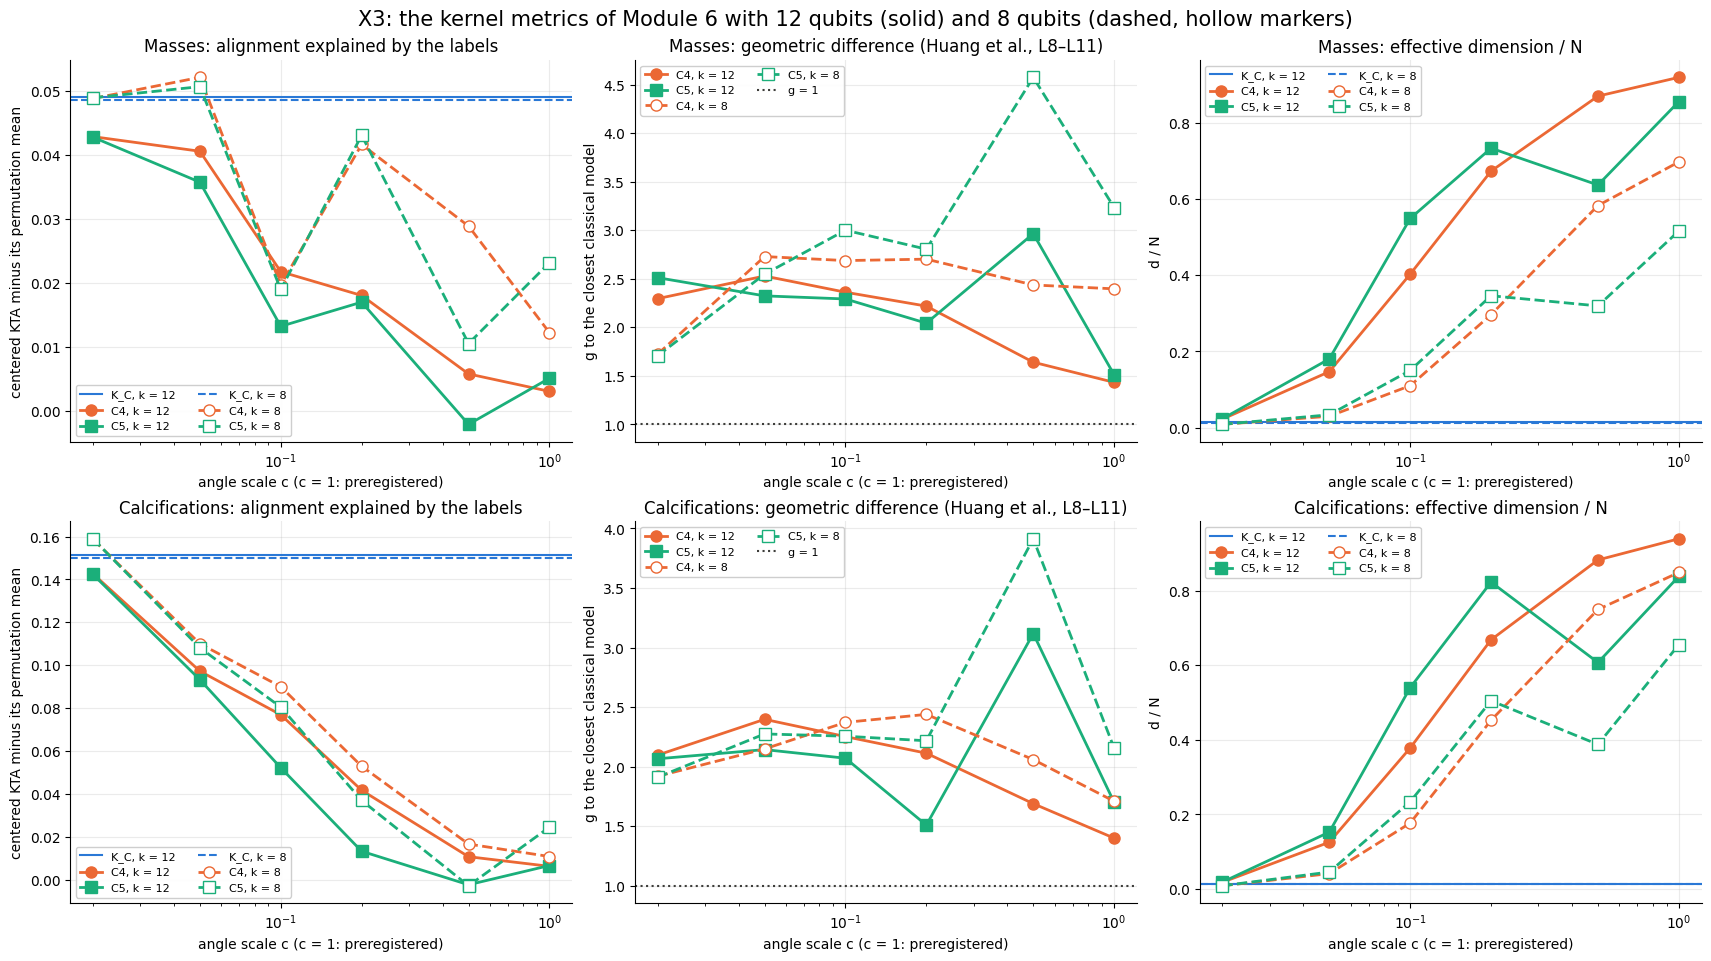

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9.5), constrained_layout=True)
for row, ft in enumerate(FINDINGS):
    for k, ls in [(12, '-'), (8, '--')]:
        kk, gg, dd = (df[(df.k == k) & (df.finding_type == ft)] for df in (kta, gsum, dims))
        axes[row, 0].axhline(kk[kk.kernel == 'K_C'].excess_centered.iloc[0], color=COLORS['K_C'], ls=ls, lw=1.5,
                             label=f'K_C, k = {k}')
        axes[row, 2].axhline(dd[dd.kernel == 'K_C'].effective_dimension.iloc[0] / 200, color=COLORS['K_C'], ls=ls, lw=1.5,
                             label=f'K_C, k = {k}')
        for q in QUANTUM:
            for col, df, ycol, scale in [(0, kk, 'excess_centered', 1), (1, gg, 'g_min', 1), (2, dd, 'effective_dimension', 1 / 200)]:
                s = df[(df[('kernel' if col != 1 else 'map')] == q)].sort_values('c')
                axes[row, col].plot(s.c, s[ycol] * scale, ls=ls, marker=MARKERS[q], color=COLORS[q],
                                    markerfacecolor=COLORS[q] if k == 12 else 'white', label=f'{q}, k = {k}')
    axes[row, 1].axhline(1, color=INK, ls=':', lw=1.5, label='g = 1')
    titles = ['alignment explained by the labels', 'geometric difference (Huang et al., L8–L11)', 'effective dimension / N']
    ylabels = ['centered KTA minus its permutation mean', 'g to the closest classical model', 'd / N']
    for col in range(3):
        axes[row, col].set(xscale='log', xlabel='angle scale c (c = 1: preregistered)', ylabel=ylabels[col],
                           title=f'{TITLES[ft]}: {titles[col]}')
        axes[row, col].legend(fontsize=8, ncol=2, framealpha=0.95)
fig.suptitle('X3: the kernel metrics of Module 6 with 12 qubits (solid) and 8 qubits (dashed, hollow markers)', fontsize=15)
fig.savefig(FIG_DIR / 'X3_kernel_metrics_k8_k12.png', dpi=170, bbox_inches='tight')
plt.show()

**c.** Figure: the embedding metrics on the full training split. Solid bars are $k=12$ and hatched bars $k=8$; each condition keeps its color.

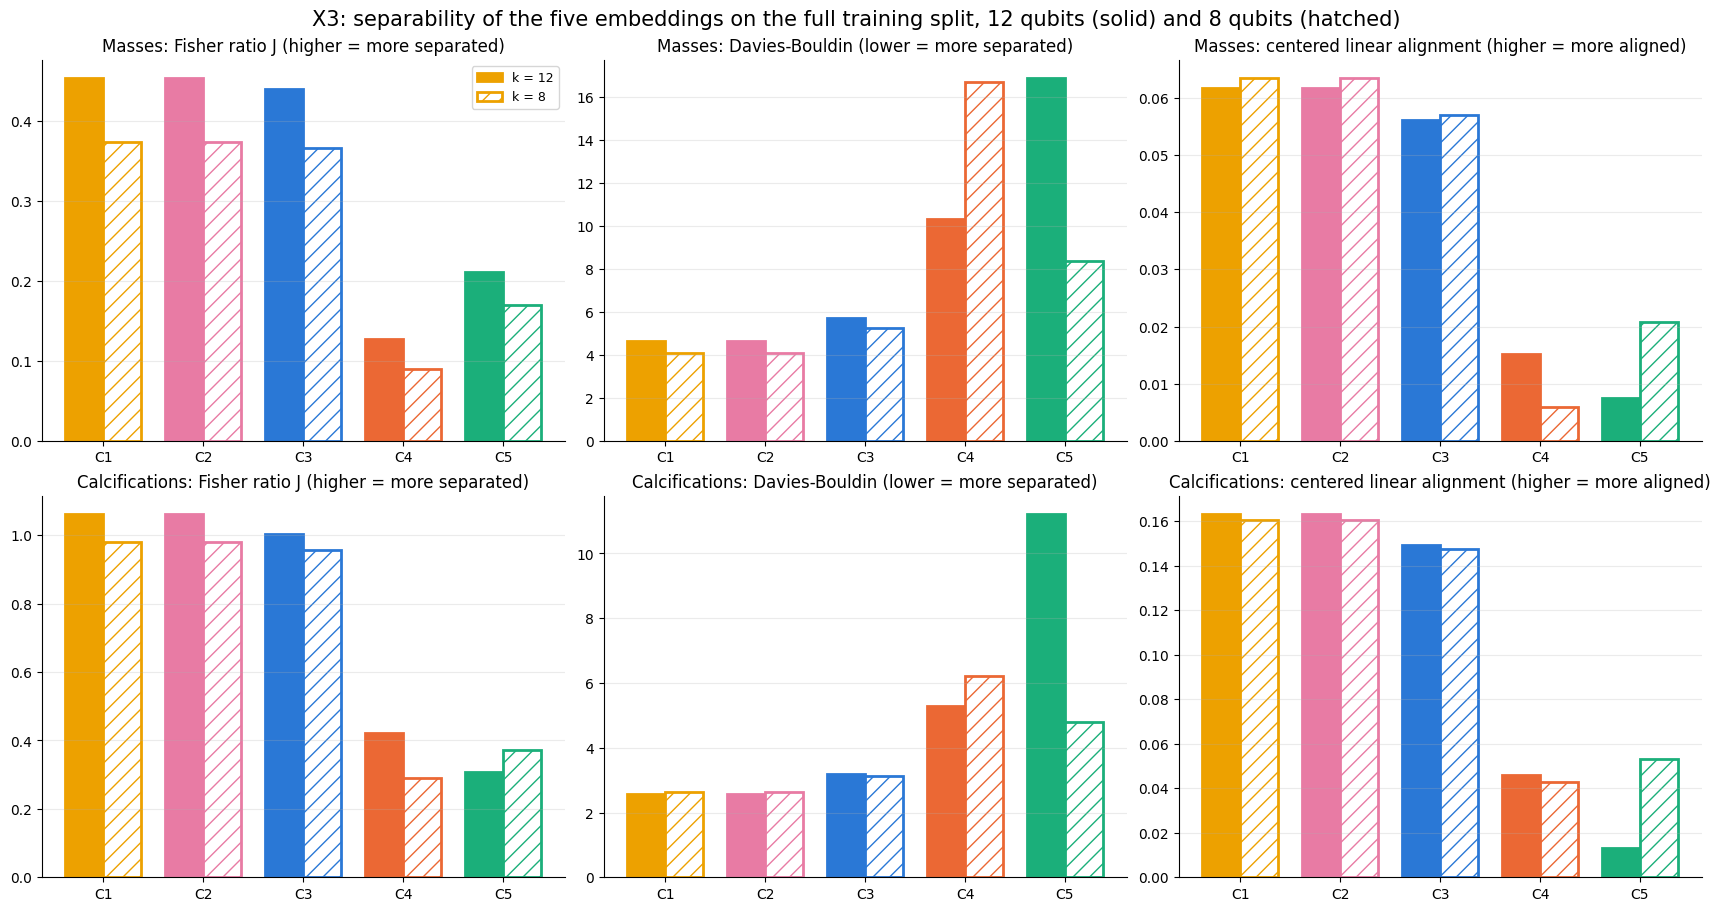

In [12]:
metrics = [('fisher_j', 'Fisher ratio J (higher = more separated)'), ('davies_bouldin', 'Davies-Bouldin (lower = more separated)'),
           ('kta_linear', 'centered linear alignment (higher = more aligned)')]
fig, axes = plt.subplots(2, 3, figsize=(17, 9), constrained_layout=True)
pos, w = np.arange(len(CONDITIONS)), 0.38
for row, ft in enumerate(FINDINGS):
    for col, (metric, label) in enumerate(metrics):
        ax = axes[row, col]
        for i, k in enumerate(KS):
            e = embm[(embm.k == k) & (embm.finding_type == ft) & (embm['sample'] == 'full train')].set_index('condition').loc[CONDITIONS]
            ax.bar(pos + (i - 0.5) * w, e[metric], width=w, color=[COLORS[c] if k == 12 else 'white' for c in CONDITIONS],
                   edgecolor=[COLORS[c] for c in CONDITIONS], hatch=None if k == 12 else '//', linewidth=2, label=f'k = {k}')
        ax.set_xticks(pos, CONDITIONS)
        ax.grid(axis='x', visible=False)
        ax.set(title=f'{TITLES[ft]}: {label}')
        if row == 0 and col == 0:
            ax.legend(fontsize=9)
fig.suptitle('X3: separability of the five embeddings on the full training split, 12 qubits (solid) and 8 qubits (hatched)', fontsize=15)
fig.savefig(FIG_DIR / 'X3_embedding_metrics_k8_k12.png', dpi=170, bbox_inches='tight')
plt.show()

#### **6° Verifications**

In [13]:
verifications = pd.DataFrame(checks)
verifications.to_csv(RESULTS_DIR / 'X3_verificaciones.csv', index=False)
display(verifications)
print(f'Checks passed: {int(verifications.passed.sum())}/{len(verifications)}')

,check,value,passed
0,mass: the 8 features are the first 8 of the 12...,0.000000e+00,True
1,mass: the angles of k = 8 equal the first 8 co...,0.000000e+00,True
2,calcification: the 8 features are the first 8 ...,0.000000e+00,True
3,calcification: the angles of k = 8 equal the f...,0.000000e+00,True
4,theta of k = 8 is the first 16 draws of the se...,0.000000e+00,True
5,mass: C4 local Z agrees with SparsePauliOp (le...,8.326673e-17,True
6,mass: C4 local Z agrees with SparsePauliOp (le...,3.868433e-16,True
7,mass: C4 local Z agrees with SparsePauliOp (le...,2.151057e-16,True
8,mass: C1 and C2 keep the same train distances,2.315995e-13,True
9,calcification: C4 local Z agrees with SparsePa...,2.515349e-16,True


Checks passed: 29/29


#### **7° Consequence**

**1. With 8 qubits the quantum kernels are less concentrated and see somewhat more of the classes, as H-018 anticipated.**

| $c=1$, 200 lesions | Masses, $k=12$ | Masses, $k=8$ | Calcifications, $k=12$ | Calcifications, $k=8$ |
|---|---|---|---|---|
| Median kernel value, C4 / C5 | 0.002 / 0.00003 | 0.010 / 0.0015 | 0.003 / 0.00003 | 0.008 / 0.0008 |
| Effective dimension, C4 / C5 (of 200) | 184 / 171 | 140 / 103 | 188 / 168 | 170 / 131 |
| KTA excess, C4 / C5 | 0.003 / 0.005 | 0.012 / 0.023 | 0.006 / 0.007 | 0.011 / 0.024 |
| KTA excess of the RBF kernel | 0.049 | 0.049 | 0.151 | 0.150 |
| Minimum $g$, C4 / C5 ($\sqrt{N}=14.1$) | 1.43 / 1.51 | 2.40 / 3.23 | 1.40 / 1.70 | 1.71 / 2.16 |
| Embedding dispersion, C4 / C5 (full train) | 0.057 / 0.180 | 0.099 / 0.276 | 0.048 / 0.178 | 0.076 / 0.267 |

- **Fewer qubits, less concentration.** The kernel and the embedding are less concentrated with fewer qubits, as H-018 predicted. The embedding dispersion of C4 goes from 0.057 to 0.099 in masses.
- **The alignment explained by the labels grows between 1.7 and 4.6 times.** The largest value is C5 in masses, with about half of the RBF excess (0.023 against 0.049); in calcifications C5 keeps 16 % of it.
- **The quantum kernels stay below the classical one at the preregistered scale.** Only at the smallest scales do they reach its level: at $c=0.05$ in masses and at $c=0.02$ in calcifications, the excess of C4 and C5 is within 0.009 of the RBF, at most 1.3 standard deviations of the permutation null. At those scales the kernel is practically the kernel of a map without the product term $x_ix_j$ (H-031), so what it recovers is what the classical kernel already sees.

**2. The geometric difference grows a little and stays small.** With 8 qubits the quantum kernels are less close to the identity, so the closest classical model is further away: between 1.7 and 3.2 at $c=1$, and at most 4.6 in the whole sweep (C5 in masses at $c=0.5$). Every value stays far below $\sqrt{N}=14.1$, the regime of the flowchart of Huang et al. in which classical ML predicts similarly or better for any labels.

**3. The embeddings keep their ordering.** On the full training split, C1–C3 stay well ahead of C4 and C5 in every metric and subset. Fewer features cost the classical conditions too: the Fisher ratio of C1 goes from 0.45 to 0.37 in masses and from 1.06 to 0.98 in calcifications. The quantum-to-classical ratio does not improve systematically. For C5 against C1 it is 0.47 at $k=12$ and 0.45 at $k=8$ in masses, and 0.29 and 0.38 in calcifications; for C4 it falls in both subsets.

C4 and C5 move in opposite directions with $k$: C5 improves in Davies-Bouldin and linear alignment, while C4 worsens. That is consistent with C5 gaining dispersion from its Y term (H-037).

**4. Answer to Q-013.** The conclusion of Module 6 does not depend on having used 12 qubits. With 8 qubits the concentration diminishes and the quantum kernels capture more class structure, which quantifies the cost of concentration for the OE-6. Still, no metric shows the quantum transformations ahead of the classical ones at the preregistered scale. The two values of $k$ share the first 8 features, the subsample, the seed and the procedures, and the regression check reproduces Module 6 exactly. The difference between them is therefore the number of qubits, together with the four features that $k=12$ adds. In masses those four include all three texture features, so $k=8$ keeps none (H-026).


In [14]:
print('=' * 86)
print('X3 - SEPARABILITY WITH 8 QUBITS AGAINST 12 - SUMMARY (c = 1; 200 lesions; Fisher on full train)')
print('=' * 86)
for ft in FINDINGS:
    print(f'  {TITLES[ft]}')
    for k in KS:
        ka = kta[(kta.k == k) & (kta.finding_type == ft) & (kta.c.isna() | (kta.c == 1.0))].set_index('kernel')
        di = dims[(dims.k == k) & (dims.finding_type == ft) & (dims.c.isna() | (dims.c == 1.0))].set_index('kernel')
        gs = gsum[(gsum.k == k) & (gsum.finding_type == ft) & (gsum.c.isna() | (gsum.c == 1.0))].set_index('map')
        e = embm[(embm.k == k) & (embm.finding_type == ft) & (embm['sample'] == 'full train')].set_index('condition')
        print(f"    k = {k:2d} | KTA excess K_C {ka.loc['K_C', 'excess_centered']:.4f}, C4 {ka.loc['C4', 'excess_centered']:.4f}, "
              f"C5 {ka.loc['C5', 'excess_centered']:.4f} | d C4 {di.loc['C4', 'effective_dimension']:.0f}, "
              f"C5 {di.loc['C5', 'effective_dimension']:.0f} | g C4 {gs.loc['C4', 'g_min']:.2f}, C5 {gs.loc['C5', 'g_min']:.2f}")
        print(f"           | Fisher J " + ', '.join(f"{c} {e.loc[c, 'fisher_j']:.2f}" for c in CONDITIONS))
print(f"  Checks passed: {int(verifications.passed.sum())}/{len(verifications)}")
print('=' * 86)

X3 - SEPARABILITY WITH 8 QUBITS AGAINST 12 - SUMMARY (c = 1; 200 lesions; Fisher on full train)
  Masses
    k = 12 | KTA excess K_C 0.0491, C4 0.0030, C5 0.0051 | d C4 184, C5 171 | g C4 1.43, C5 1.51
           | Fisher J C1 0.45, C2 0.45, C3 0.44, C4 0.13, C5 0.21
    k =  8 | KTA excess K_C 0.0487, C4 0.0122, C5 0.0232 | d C4 140, C5 103 | g C4 2.40, C5 3.23
           | Fisher J C1 0.37, C2 0.37, C3 0.37, C4 0.09, C5 0.17
  Calcifications
    k = 12 | KTA excess K_C 0.1515, C4 0.0062, C5 0.0066 | d C4 188, C5 168 | g C4 1.40, C5 1.70
           | Fisher J C1 1.06, C2 1.06, C3 1.00, C4 0.42, C5 0.31
    k =  8 | KTA excess K_C 0.1498, C4 0.0108, C5 0.0245 | d C4 170, C5 131 | g C4 1.71, C5 2.16
           | Fisher J C1 0.98, C2 0.98, C3 0.96, C4 0.29, C5 0.37
  Checks passed: 29/29
